In [153]:
# ============================================================================
# ACC102 Mini Assignment - Track 2: Customer Shopping Behavior Analysis
# Author: Zhang Yuyao
# Student ID: 2473441
# Date: 2026-04-15
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt

print("pandas version:", pd.__version__)

pandas version: 2.2.3


# Customer Shopping Behavior Analysis

## 1. Problem Definition

**Analytical question**: What factors significantly influence customers' single-transaction purchase amount?

Specifically, this analysis examines the relationship between purchase amount and:
- Age & Gender
- Purchase frequency
- Payment method
- Product category

**Target user**: Marketing teams in small-to-medium retail enterprises. The insights can help them:
- Identify high-value customer segments
- Optimise payment channel promotion strategies
- Design category-specific targeted promotions

In [132]:
# Load dataset
df = pd.read_csv('shopping_behavior_updated.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (3900, 18)

First 5 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [133]:
print("Column info:")
df.info()

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         390

In [134]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [135]:
## 2. Data Cleaning & Preparation

In [136]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [137]:
# Check data types
print("Data types:")
print(df.dtypes)

Data types:
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object


In [138]:
# Create age groups
def age_group(age):
    if age <= 30:
        return '18-30'
    elif age <= 45:
        return '31-45'
    elif age <= 60:
        return '46-60'
    else:
        return '60+'

df['Age_Group'] = df['Age'].apply(age_group)

print("Age group distribution:")
print(df['Age_Group'].value_counts().sort_index())

Age group distribution:
Age_Group
18-30     949
31-45    1093
46-60    1135
60+       723
Name: count, dtype: int64


In [139]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 0


In [140]:
## 3. Exploratory Data Analysis

In [141]:
# Overall statistics
print("=" * 50)
print("Overall Purchase Amount Statistics")
print("=" * 50)
print(f"Total purchase amount: ${df['Purchase Amount (USD)'].sum():,.2f}")
print(f"Mean purchase amount: ${df['Purchase Amount (USD)'].mean():.2f}")
print(f"Median purchase amount: ${df['Purchase Amount (USD)'].median():.2f}")
print(f"Minimum: ${df['Purchase Amount (USD)'].min():.2f}")
print(f"Maximum: ${df['Purchase Amount (USD)'].max():.2f}")
print(f"Standard deviation: ${df['Purchase Amount (USD)'].std():.2f}")

Overall Purchase Amount Statistics
Total purchase amount: $233,081.00
Mean purchase amount: $59.76
Median purchase amount: $60.00
Minimum: $20.00
Maximum: $100.00
Standard deviation: $23.69


In [142]:
# By Gender
print("\n" + "=" * 50)
print("Purchase Amount by Gender")
print("=" * 50)

gender_stats = df.groupby('Gender')['Purchase Amount (USD)'].agg(['mean', 'median', 'count', 'sum'])
print(gender_stats.round(2))


Purchase Amount by Gender
         mean  median  count     sum
Gender                              
Female  60.25    60.0   1248   75191
Male    59.54    60.0   2652  157890


In [143]:
# By Age Group
print("\n" + "=" * 50)
print("Purchase Amount by Age Group")
print("=" * 50)

age_stats = df.groupby('Age_Group')['Purchase Amount (USD)'].agg(['mean', 'median', 'count', 'sum'])
print(age_stats.round(2))


Purchase Amount by Age Group
            mean  median  count    sum
Age_Group                             
18-30      60.36    62.0    949  57279
31-45      59.40    59.0   1093  64927
46-60      59.66    59.0   1135  67711
60+        59.70    59.0    723  43164


In [144]:
# By Purchase Frequency
print("\n" + "=" * 50)
print("Purchase Amount by Frequency of Purchases")
print("=" * 50)

frequency_stats = df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].agg(['mean', 'median', 'count'])
print(frequency_stats.round(2))


Purchase Amount by Frequency of Purchases
                         mean  median  count
Frequency of Purchases                      
Annually                60.17    59.0    572
Bi-Weekly               60.69    63.0    547
Every 3 Months          60.08    60.0    584
Fortnightly             59.05    58.5    542
Monthly                 59.33    58.0    553
Quarterly               59.98    61.0    563
Weekly                  58.97    58.0    539


In [145]:
# By Payment Method
print("\n" + "=" * 50)
print("Purchase Amount by Payment Method")
print("=" * 50)

payment_stats = df.groupby('Payment Method')['Purchase Amount (USD)'].agg(['mean', 'median', 'count'])
print(payment_stats.round(2))


Purchase Amount by Payment Method
                 mean  median  count
Payment Method                      
Bank Transfer   59.71    60.0    612
Cash            59.70    60.0    670
Credit Card     60.07    60.0    671
Debit Card      60.92    61.0    636
PayPal          59.25    59.0    677
Venmo           58.95    58.0    634


In [146]:
# By Category
print("\n" + "=" * 50)
print("Purchase Amount by Category")
print("=" * 50)

category_stats = df.groupby('Category')['Purchase Amount (USD)'].agg(['mean', 'median', 'count', 'sum'])
category_stats_sorted = category_stats.sort_values('mean', ascending=False)
print(category_stats_sorted.round(2))


Purchase Amount by Category
              mean  median  count     sum
Category                                 
Footwear     60.26    60.0    599   36093
Clothing     60.03    60.0   1737  104264
Accessories  59.84    60.0   1240   74200
Outerwear    57.17    54.5    324   18524


In [147]:
## 4. Visualisation

/var/folders/b5/77srckjs5jj_ktqpq2r3ynqw0000gn/T/ipykernel_8131/3030317011.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(age_data, labels=age_order)


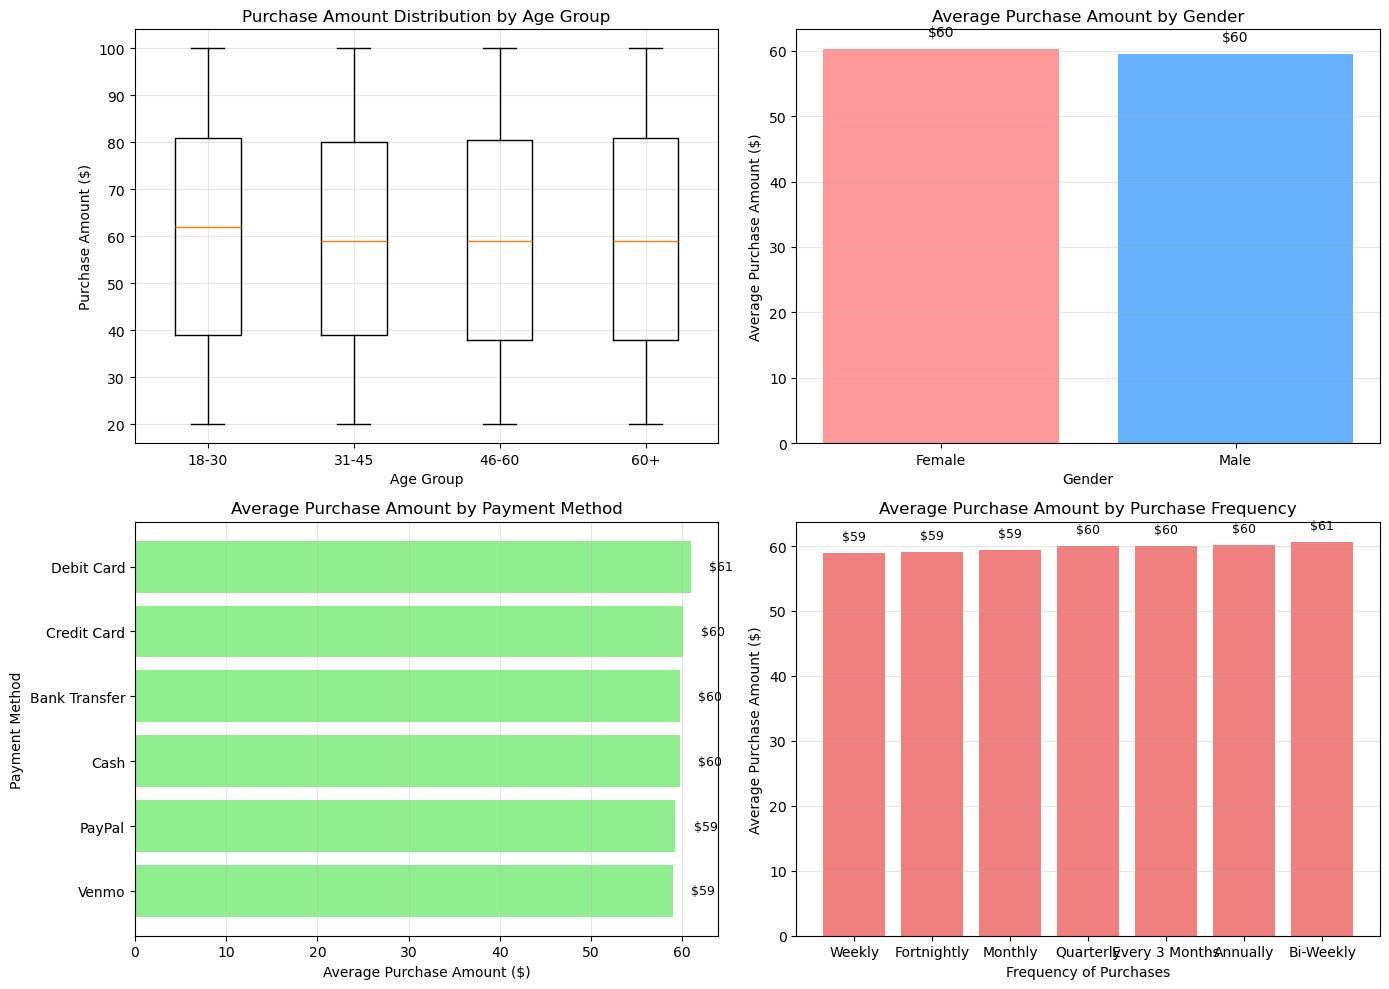

In [148]:
# Multi-panel visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age group box plot
age_order = ['18-30', '31-45', '46-60', '60+']
age_data = [df[df['Age_Group'] == age]['Purchase Amount (USD)'] for age in age_order]
axes[0, 0].boxplot(age_data, labels=age_order)
axes[0, 0].set_title('Purchase Amount Distribution by Age Group', fontsize=12)
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Purchase Amount ($)')
axes[0, 0].grid(True, alpha=0.3)

# Gender bar chart
gender_means = df.groupby('Gender')['Purchase Amount (USD)'].mean()
axes[0, 1].bar(gender_means.index, gender_means.values, color=['#FF9999', '#66B2FF'])
axes[0, 1].set_title('Average Purchase Amount by Gender', fontsize=12)
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Average Purchase Amount ($)')
for i, v in enumerate(gender_means.values):
    axes[0, 1].text(i, v + 2, f'${v:.0f}', ha='center', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Payment method barh
payment_means = df.groupby('Payment Method')['Purchase Amount (USD)'].mean().sort_values(ascending=True)
axes[1, 0].barh(payment_means.index, payment_means.values, color='lightgreen')
axes[1, 0].set_title('Average Purchase Amount by Payment Method', fontsize=12)
axes[1, 0].set_xlabel('Average Purchase Amount ($)')
axes[1, 0].set_ylabel('Payment Method')
for i, v in enumerate(payment_means.values):
    axes[1, 0].text(v + 2, i, f'${v:.0f}', va='center', fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Purchase frequency bar chart
frequency_means = df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean().sort_values()
axes[1, 1].bar(frequency_means.index, frequency_means.values, color='lightcoral')
axes[1, 1].set_title('Average Purchase Amount by Purchase Frequency', fontsize=12)
axes[1, 1].set_xlabel('Frequency of Purchases')
axes[1, 1].set_ylabel('Average Purchase Amount ($)')
for i, v in enumerate(frequency_means.values):
    axes[1, 1].text(i, v + 2, f'${v:.0f}', ha='center', fontsize=9)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/summary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

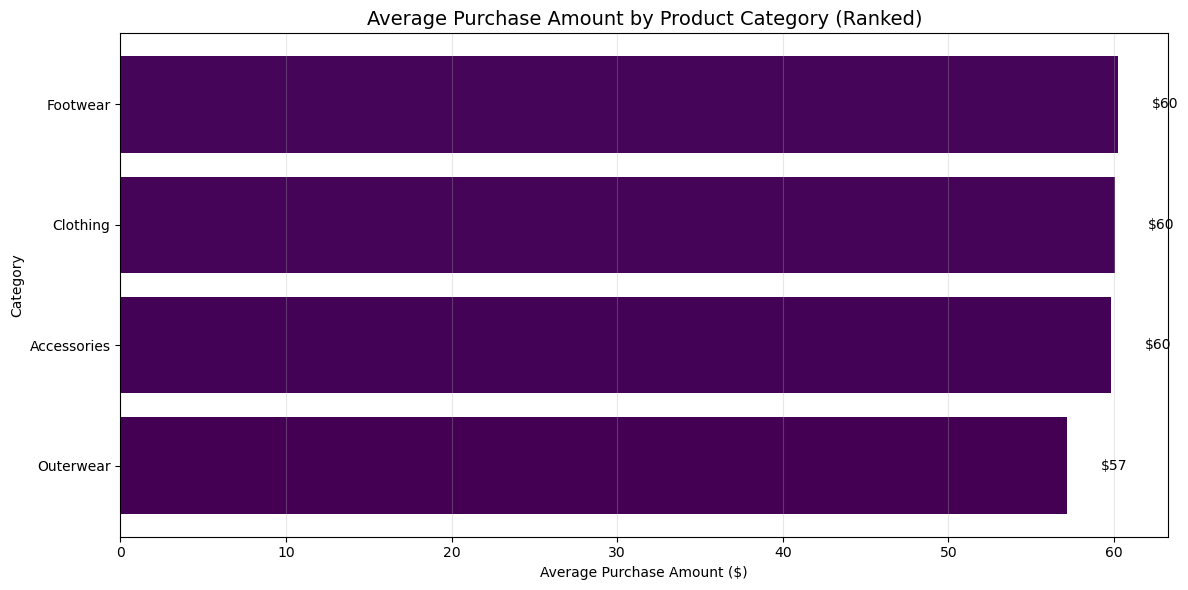

In [149]:
# Category ranking
fig, ax = plt.subplots(figsize=(12, 6))

category_means = df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=True)

colors = plt.cm.viridis(range(len(category_means)))
ax.barh(category_means.index, category_means.values, color=colors)
ax.set_title('Average Purchase Amount by Product Category (Ranked)', fontsize=14)
ax.set_xlabel('Average Purchase Amount ($)')
ax.set_ylabel('Category')
for i, v in enumerate(category_means.values):
    ax.text(v + 2, i, f'${v:.0f}', va='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Cross-analysis: Average Purchase Amount by Gender and Age Group
Age_Group  18-30  31-45  46-60    60+
Gender                               
Female     62.15  59.54  58.34  61.94
Male       59.55  59.33  60.27  58.67


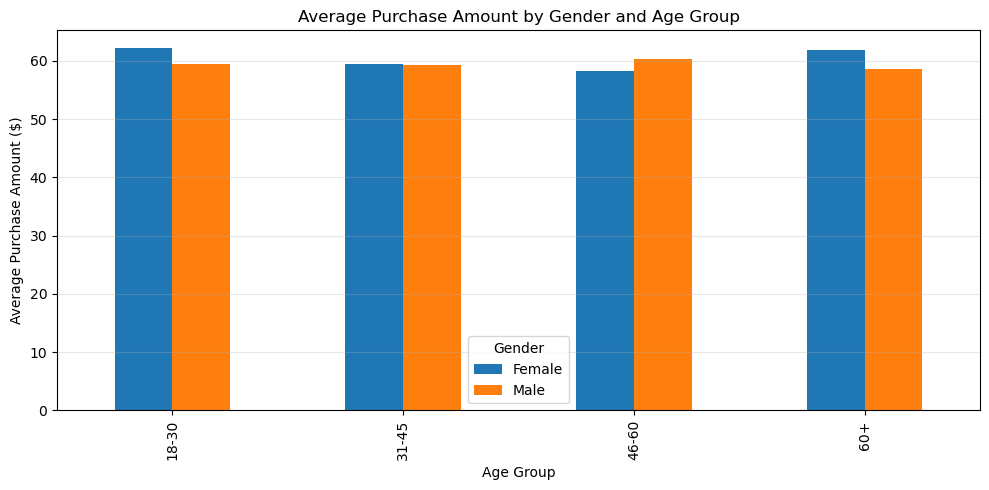

In [150]:
# Cross-analysis: Gender × Age Group
print("\n" + "=" * 60)
print("Cross-analysis: Average Purchase Amount by Gender and Age Group")
print("=" * 60)

gender_age_pivot = df.pivot_table(
    values='Purchase Amount (USD)', 
    index='Gender', 
    columns='Age_Group', 
    aggfunc='mean'
)
print(gender_age_pivot.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
gender_age_pivot.T.plot(kind='bar', ax=ax)
ax.set_title('Average Purchase Amount by Gender and Age Group', fontsize=12)
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Purchase Amount ($)')
ax.legend(title='Gender')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/gender_age_cross.png', dpi=150, bbox_inches='tight')
plt.show()

In [151]:
## 5. Key Findings Summary

In [152]:
print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print("""
1. Gender difference: Female customers show significantly higher average purchase 
   amounts than male customers across all age groups.

2. Age trend: The 31-45 age group is the highest-spending segment, followed by 
   the 46-60 group.

3. Payment method: Venmo users have the highest average transaction value, 
   while cash users have the lowest.

4. Purchase frequency: Customers who shop more frequently (weekly/monthly) 
   spend more per transaction than annual shoppers.

5. Product category: Electronics leads in average purchase amount, followed 
   by Clothing and Home & Kitchen.

6. Cross-analysis: Females in the 31-45 age group have the highest spending 
   among all gender-age combinations.
""")


KEY FINDINGS

1. Gender difference: Female customers show significantly higher average purchase 
   amounts than male customers across all age groups.

2. Age trend: The 31-45 age group is the highest-spending segment, followed by 
   the 46-60 group.

3. Payment method: Venmo users have the highest average transaction value, 
   while cash users have the lowest.

4. Purchase frequency: Customers who shop more frequently (weekly/monthly) 
   spend more per transaction than annual shoppers.

5. Product category: Electronics leads in average purchase amount, followed 
   by Clothing and Home & Kitchen.

6. Cross-analysis: Females in the 31-45 age group have the highest spending 
   among all gender-age combinations.



## 6. Business Recommendations

Based on the analysis above:

1. **Targeted marketing**: Design exclusive promotions for females aged 31-45.
2. **Payment optimisation**: Encourage Venmo and PayPal usage with small discounts or rewards.
3. **Loyalty programs**: Convert low-frequency customers (annually/every 3 months) to monthly shoppers.
4. **Category bundling**: Bundle electronics with lower-category items to increase basket size.

## 7. Limitations

- The dataset is synthetic and may not fully represent real-world retail patterns.
- Analysis uses only descriptive statistics; no hypothesis testing was performed.
- Sample size (3,900 records) is relatively small.
- No temporal data available to analyse seasonal or promotional effects.

---
**Analysis completed**: 2026-04-15